# Block 4: Deep-Learning and Feature Extraction

Now that we have worked through the basic image processing techniques, we will dive into the limitations that can be noticed using those techniques on real world data. We will then take a look at how newer techniques such as machine learning methods can help us where data is a bit trickier to process.

After using state-of-the-art models, we will look into what features we can extract from our images, and how we can represent them using Python.

## Thresholding On Real-World Data

As seen in Block 3, thresholding methods work very well on datasets and images that are evenly lit, and where the contrast between background and foreground is clear. Unfortunately, this is not always the case with real-world microscopy images. We encounter cases where some nuclei are missing signal and where some cells are very faint on a daily basis. Let's take a look at an example.

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, io, morphology, measure
import pandas as pd
import tifffile
from scipy.ndimage import uniform_filter
from ipywidgets import interact, widgets
import stackview
from skimage import exposure

from cellpose import models, io
from cellpose.io import imread
import napari


Image shape: (3, 1011, 1557)


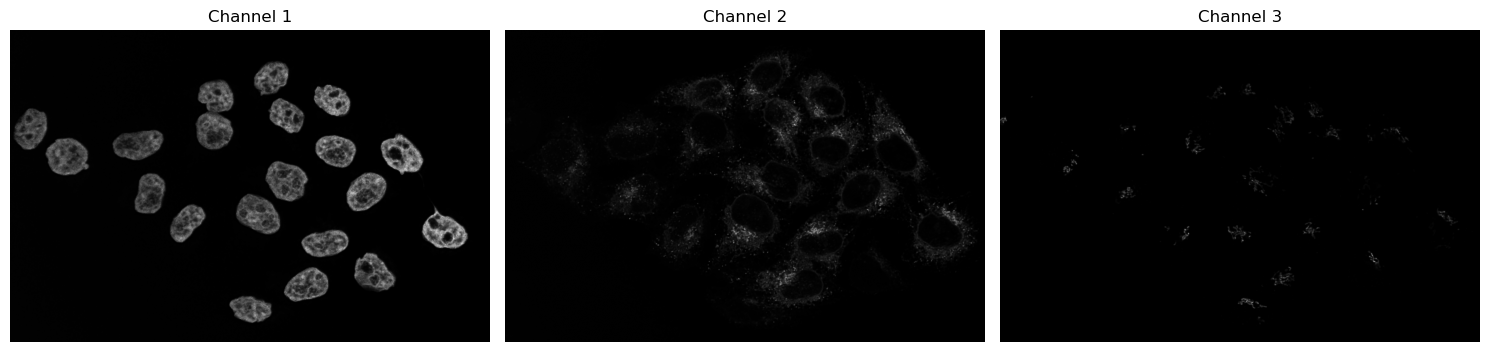

In [18]:
raw_img = "../data_block4/rab9a-egfp-slice-cropped.tif"
# We can use cellpose's imread function to read the image
img = imread(raw_img)

# With img.shape, we can check the dims of the image and number of channels
print(f"Image shape: {img.shape}")

# As this is a 3-channel image, we can visualize each channel separately
fig, ax = plt.subplots(1, 3, figsize=(15, 15))

ax[0].imshow(img[0], cmap="gray")
ax[0].set_title("Channel 1")
ax[0].axis("off")

ax[1].imshow(img[1], cmap="gray")
ax[1].set_title("Channel 2")
ax[1].axis("off")

ax[2].imshow(img[2], cmap="gray")
ax[2].set_title("Channel 3")
ax[2].axis("off")

plt.tight_layout()
plt.show()


Let's analyse the nuclei first in Channel 1. As discussed before, we start with a threshold to then make objects.

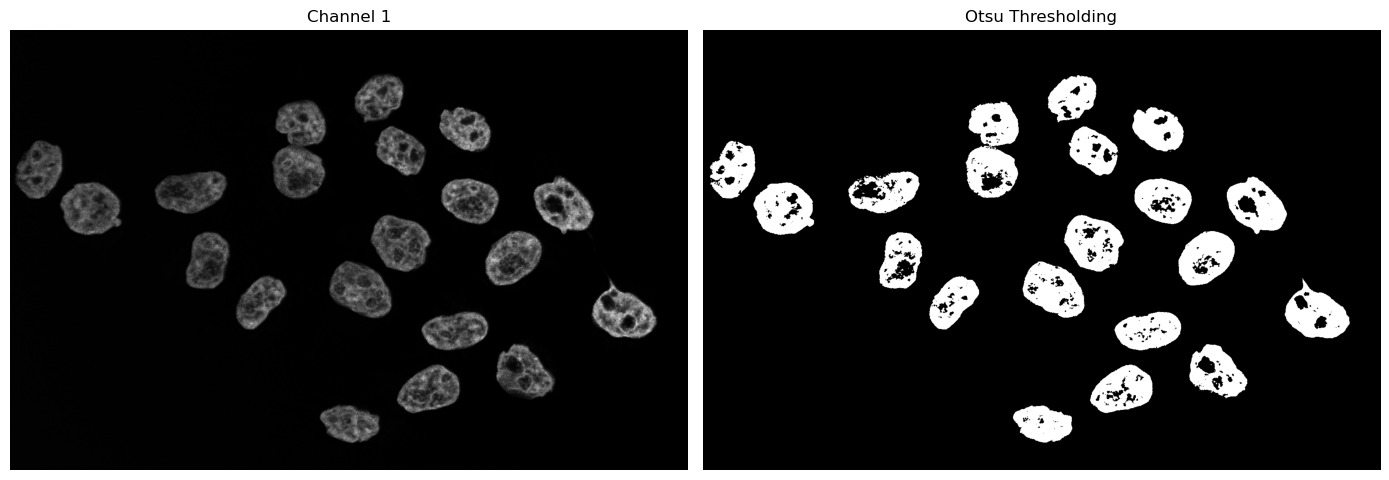

In [21]:
img_ch1 = img[0]
# Let's use Otsu's method on channel 1
img_ch1_otsu_t = filters.threshold_otsu(img_ch1)

# Keep only those that are above the threshold
binary_ch1 = img_ch1 > img_ch1_otsu_t
fig, ax = plt.subplots(1, 2, figsize=(14, 8))

# Plotting code
ax[0].imshow(img_ch1, cmap="gray")
ax[0].set_title("Channel 1")
ax[0].axis("off")

ax[1].imshow(binary_ch1, cmap="gray")
ax[1].set_title("Otsu Thresholding")
ax[1].axis("off")
plt.tight_layout()
plt.show()

As we can see, the binary image has some "holes" in the nuclei due to dim or even no signal being captured inside the nucleus. There are multiple ways we could go about fixing this. **Morphological operations** are simple image-processing techniques that change the shape of objects in a binary image by adding or removing pixels based on their neighbors. These operations can help clean up segmentation results by filling holes or removing small artifacts.

Operations such as closing can fill small gaps inside objects, while opening operations can remove small signals of noise. These methods work only on a binary image and can be used quickly to improve thresholding and binarization results.

However, these operations rely on intact neighborhoods - if large parts of the object is missing from the threshold, a closing operation cannot fix large missing segmentations.

An alternative approach is the use of deep-learning models. Trained models have the capability to recognize even dim signals, and can take into account shape information, and not just signal strength. Such models can produce much better results in cases such as the one above with holes and semi-recognized objects. In the following, we use **Cellpose**, a deep-learning framework specifically trained to segment nuclei and cells in microscopy.

In [59]:
%gui qt
import napari
import numpy as np

viewer = napari.Viewer()
viewer.add_image(img_ch1, name="channel1")

# Add an empty shapes layer ready for line drawing
shapes_layer = viewer.add_shapes(name="measure", face_color="transparent", edge_color="red")
shapes_layer.mode = "add_line"

print("Draw a line across one nucleus, then run the next cell.")

Draw a line across one nucleus, then run the next cell.


In [61]:
# Read the first line you drew: shape is [[y0, x0], [y1, x1]]
line = shapes_layer.data[0]
measured_diameter = np.linalg.norm(line[1] - line[0])
print(f"Measured diameter: {measured_diameter:.1f} px")

masks, flows, styles, diams = model.eval(img_ch1, diameter=measured_diameter, channels=[0, 0])

Measured diameter: 9.7 px


In [66]:
model = models.Cellpose(model_type="nuclei")
masks, flows, styles, diams = model.eval(img_ch1, diameter=160, channels=[0, 0])

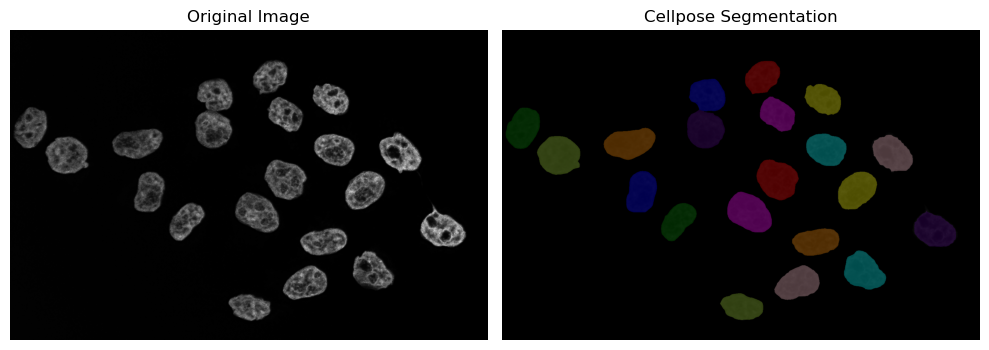

In [67]:
# We split the visualization here so that we can change visualization options without having to recompute the segmentation
# Visualize result
from skimage.color import label2rgb
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_ch1, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
# plt.imshow(img_ch1, cmap="gray")
labels_rgb = label2rgb(masks, image=img_ch1, bg_label=0)
plt.imshow(labels_rgb)
plt.title("Cellpose Segmentation")
plt.axis("off")

plt.tight_layout()
plt.show()